# EDA - HACKATON
# Dataset: Bank Customer Churn (Kaggle - gauravtopre)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# CARREGAR O CSV

CSV_PATH = '/workspaces/hackathon-churn-prediction/dados/Bank_Customer_Churn_Prediction.csv'

df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.lower()


print("Arquivo carregado com sucesso!")

Arquivo carregado com sucesso!


In [9]:
# VISÃO GERAL

print("\n🔎 HEAD")
print(df.head())

print("\n📊 INFO")
print(df.info())

print("\n📈 DESCRITIVO")
print(df.describe())

print("\n❗ VALORES NULOS")
print(df.isnull().sum())

print("\n🔁 DUPLICADOS:", df.duplicated().sum())


🔎 HEAD
   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  

📊 INFO
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Colum


🎯 DISTRIBUIÇÃO DO CHURN
churn
0    79.63
1    20.37
Name: proportion, dtype: float64


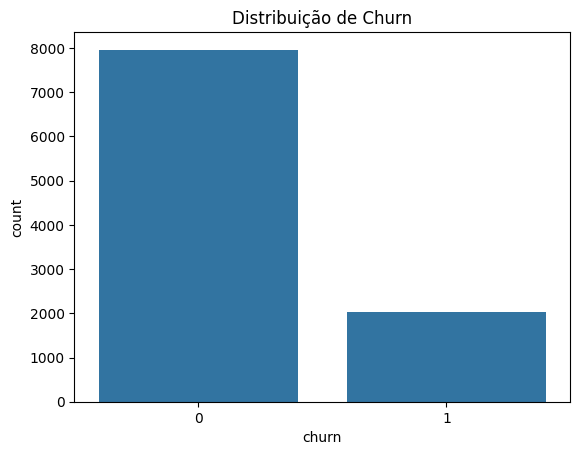

In [10]:
# TARGET

print("\n🎯 DISTRIBUIÇÃO DO CHURN")
print(df['churn'].value_counts(normalize=True) * 100)

sns.countplot(x='churn', data=df)
plt.title("Distribuição de Churn")
plt.show()

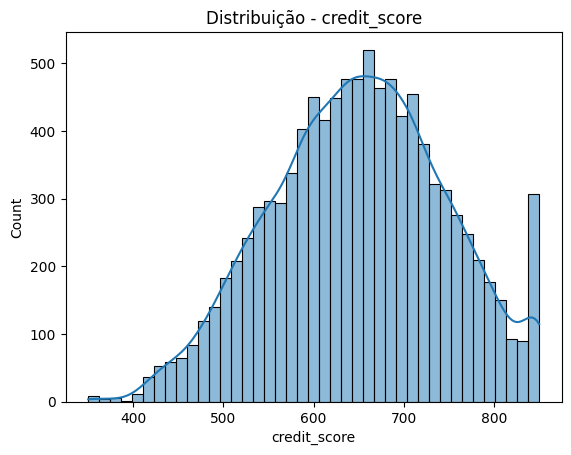

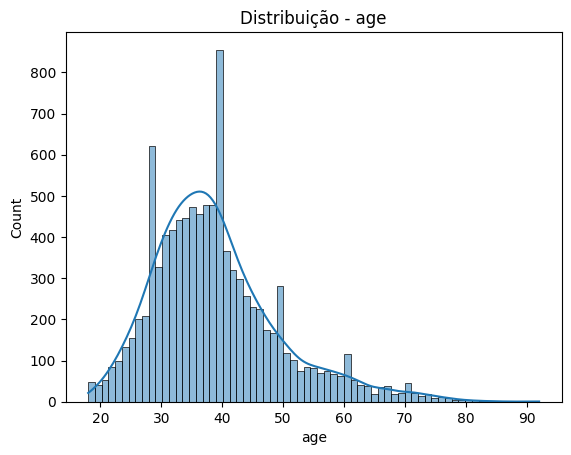

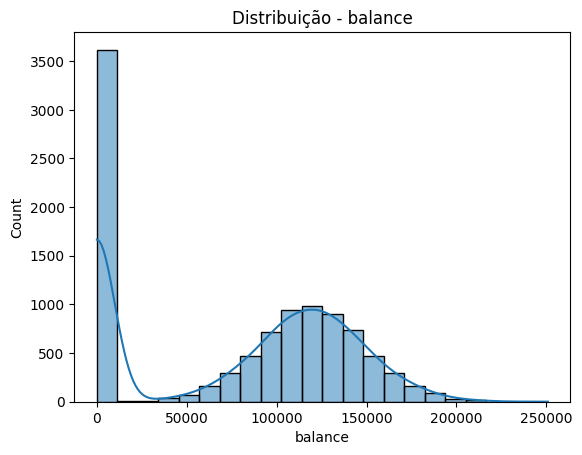

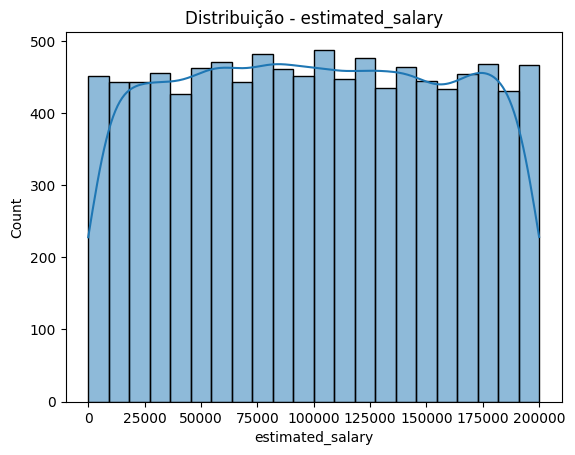

In [11]:
# NUMÉRICAS

num_cols = ['credit_score', 'age', 'balance', 'estimated_salary']

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribuição - {col}")
    plt.show()

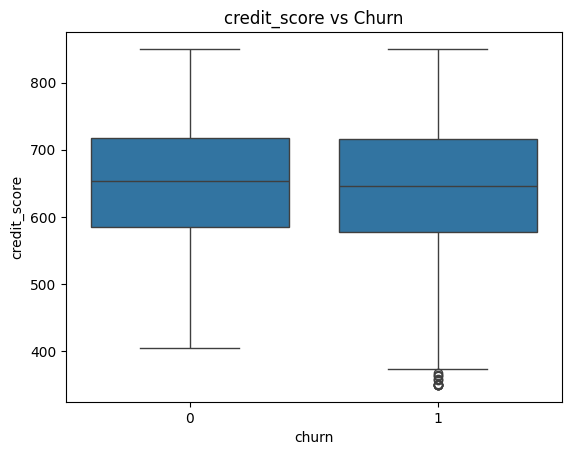

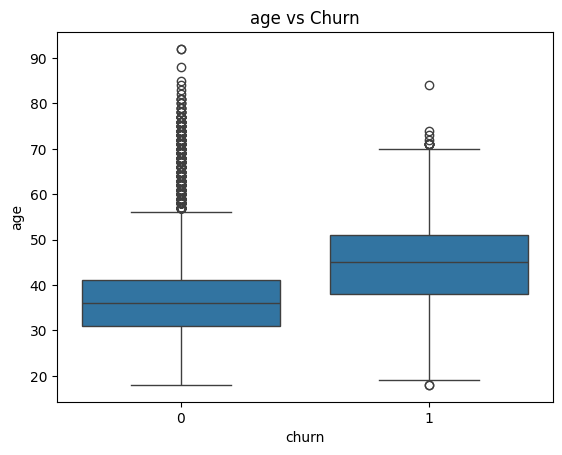

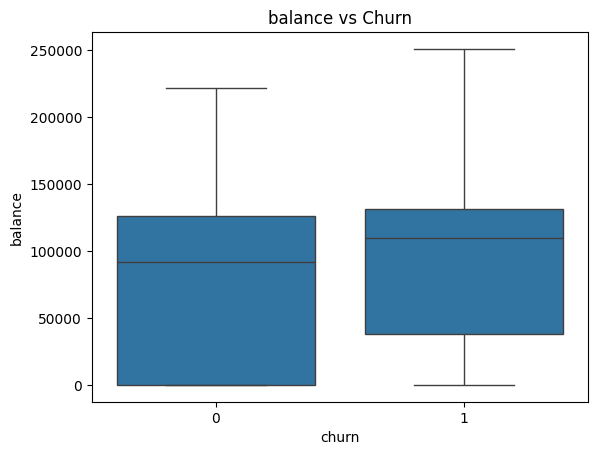

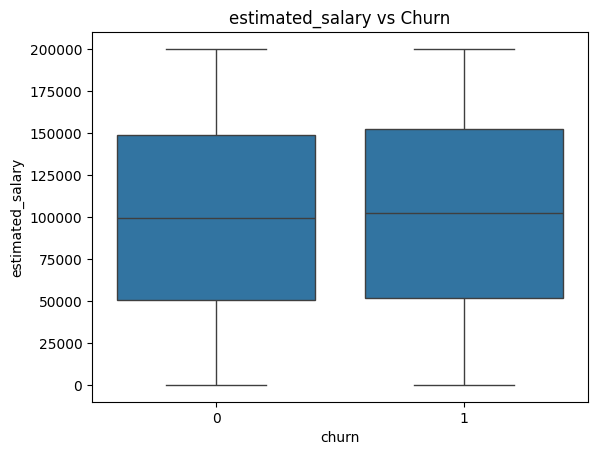

In [12]:
# CHURN VS NUMÉRICAS

for col in num_cols:
    plt.figure()
    sns.boxplot(x='churn', y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

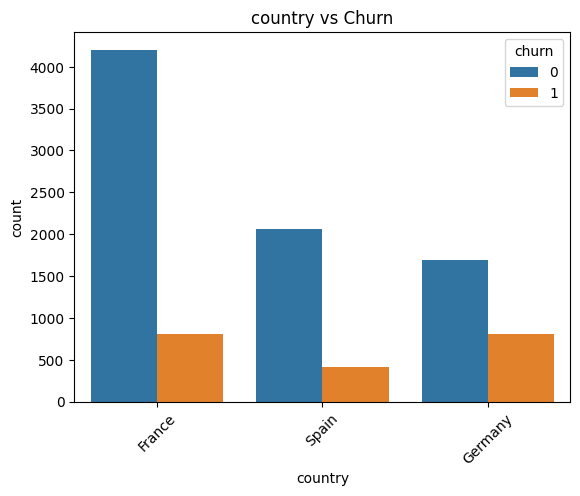

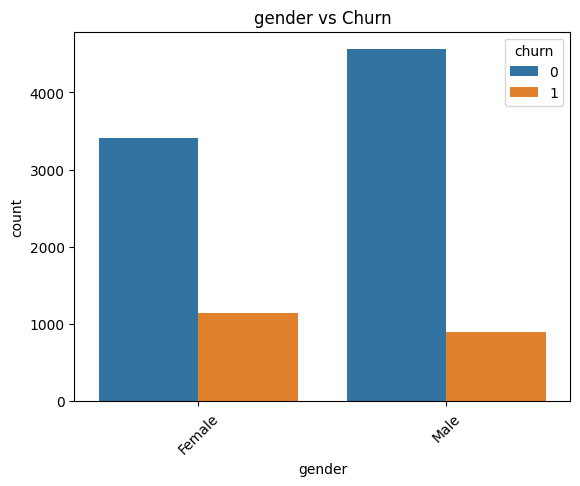

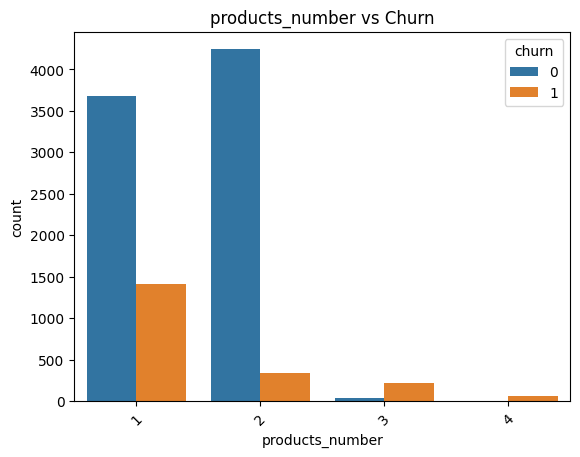

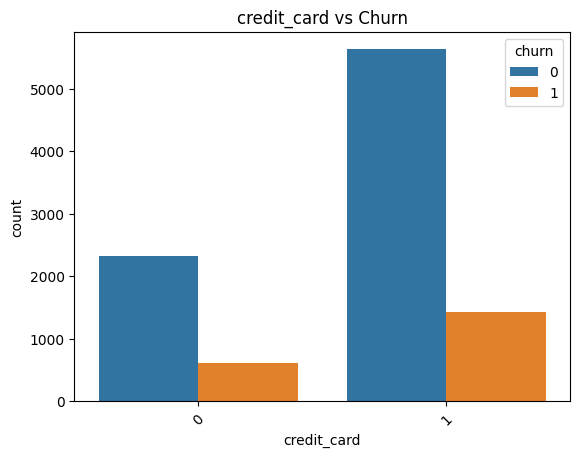

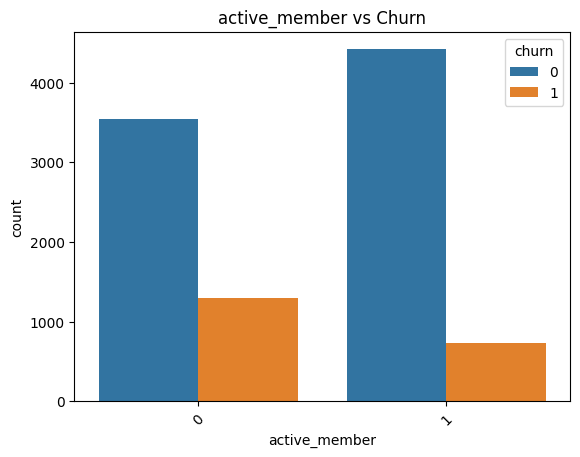

In [14]:
# CATEGÓRICAS

cat_cols = ['country', 'gender', 'products_number', 'credit_card', 'active_member']

for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, hue='churn', data=df)
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.show()


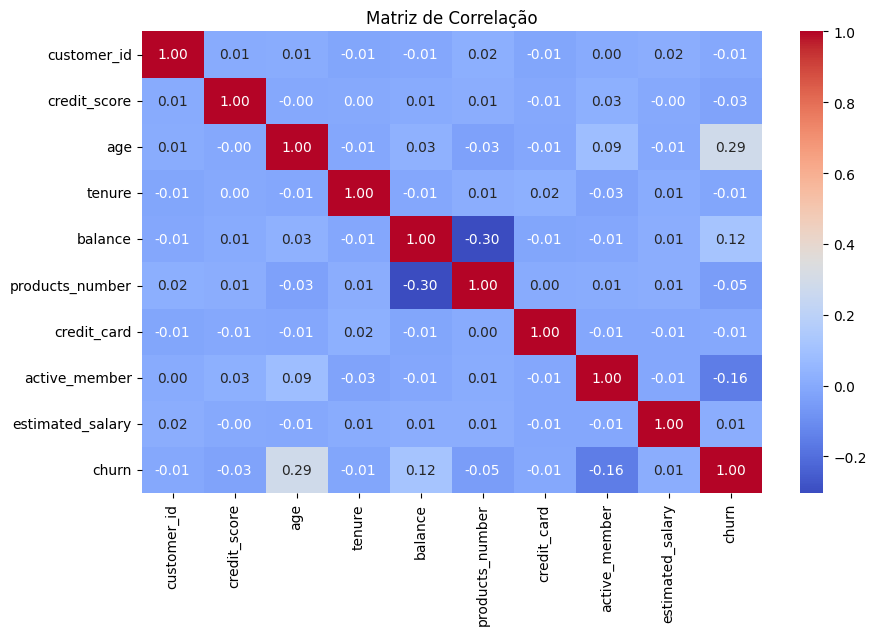

In [15]:
# CORRELAÇÃO

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

In [19]:
# BINAGEM DE IDADE

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=['<30', '30-40', '40-50', '50-60', '60+']
)

# BINAGEM DE CREDIT SCORE
df['score_group'] = pd.cut(
    df['credit_score'],
    bins=[0, 400, 600, 700, 800, 1000],
    labels=['Muito Baixo', 'Baixo', 'Médio', 'Bom', 'Excelente']
)

# CHURN POR FAIXA
age_churn = df.groupby('age_group')['churn'].mean().reset_index()
score_churn = df.groupby('score_group')['churn'].mean().reset_index()

print("\nChurn por faixa etária")
print(age_churn)

print("\nChurn por score")
print(score_churn)


Churn por faixa etária
  age_group     churn
0       <30  0.075203
1     30-40  0.120872
2     40-50  0.339655
3     50-60  0.562108
4       60+  0.247845

Churn por score
   score_group     churn
0  Muito Baixo  1.000000
1        Baixo  0.212012
2        Médio  0.197224
3          Bom  0.199110
4    Excelente  0.196899


O churn cresce drasticamente com a idade, saindo de 7% em clientes jovens para mais de 56% entre 50 e 60 anos.

Clientes com score muito baixo apresentam churn extremo, mas o volume é pequeno — o comportamento mais relevante está entre clientes de score médio a alto, onde o churn permanece estável (~20%).

In [20]:

# CRIAR COHORT (tempo de casa)
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[-1, 1, 3, 5, 10],
    labels=['0-1 anos', '1-3 anos', '3-5 anos', '5+ anos']
)


# TABELA COHORT
cohort = df.pivot_table(
    index='tenure_group',
    values='churn',
    aggfunc='mean'
).reset_index()

print("\nChurn por tempo de casa")
print(cohort)


Churn por tempo de casa
  tenure_group     churn
0     0-1 anos  0.225829
1     1-3 anos  0.201264
2     3-5 anos  0.205897
3      5+ anos  0.196707


O churn não está ligado ao risco financeiro, mas sim à falta de engajamento inicial.
Clientes mais velhos e inativos, principalmente nos primeiros meses, têm maior probabilidade de sair.

In [21]:
combo = df.pivot_table(
    index='age_group',
    columns='active_member',
    values='churn',
    aggfunc='mean'
)

print(combo)

active_member         0         1
age_group                        
<30            0.100832  0.050696
30-40          0.149374  0.092099
40-50          0.415987  0.254113
50-60          0.857143  0.347072
60+            0.820225  0.112000


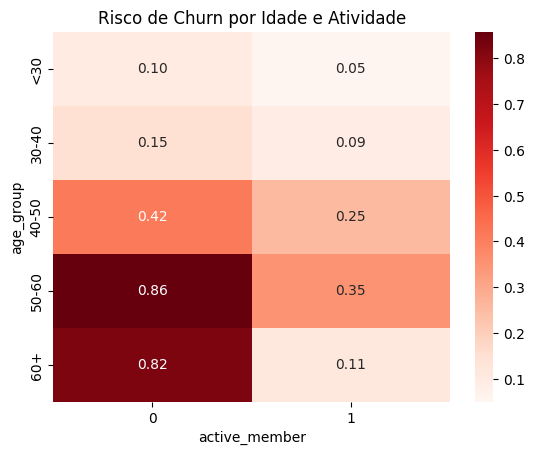

In [23]:
sns.heatmap(
    df.pivot_table(
        index='age_group',
        columns='active_member',
        values='churn',
        aggfunc='mean'
    ),
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title("Risco de Churn por Idade e Atividade")
plt.show()